# 温度駆動力を与える。固相液相の2相シミュレーションー＞GPU計算

In [1]:
import matplotlib.pyplot as plt
from numba import cuda
import math
import numpy as np
import os
# --- 定数と設定 ---
nx, ny = 256, 256
number_of_grain = 2
dx, dy = 1e-4, 1e-4
dt = 0.01
nsteps = 1000000
pi = np.pi
sigma = 1.0
delta = 10.0 * dx
T_melt = 1687.15
G = 1.0e+03
V_pulling = 1.0e-05
latent = 4.15e+04

aaa = 2.0 / pi * np.sqrt(2.0*delta*sigma)
www = 4 * sigma/delta
pmobi = pi*pi/(8.*delta)*3.0e-13

# Output
out_dir = "result/ver1"
os.makedirs(out_dir, exist_ok=True)

In [2]:
# パラメータ配列の準備
wij = np.zeros((number_of_grain, number_of_grain), dtype=np.float32)
aij = np.zeros((number_of_grain, number_of_grain), dtype=np.float32)
mij = np.zeros((number_of_grain, number_of_grain), dtype=np.float32)

for i in range(number_of_grain):
    for j in range(number_of_grain):
        if i == j: continue
        wij[i,j] = www
        aij[i,j] = aaa
        if (i == 0 and j != 0) or (i != 0 and j == 0):
            mij[i,j] = pmobi * 10000.0
        else:
            mij[i,j] = pmobi

In [3]:
# --- CUDA Kernels ---
@cuda.jit
def kernel_update_phasefield(phi, phi_new, temp, wij, aij, mij, nx, ny, number_of_grain, dx, dt, T_melt, latent):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        l_p = l + 1 if l < nx - 1 else l
        l_m = l - 1 if l > 0 else 0
        m_p = m + 1 if m < ny - 1 else m
        m_m = m - 1 if m > 0 else 0

        # 各フェーズの更新
        for i in range(number_of_grain):
            dpi = 0.0
            num_phase = 0
            # 存在しているフェーズ数をカウント（nfに相当）
            for k in range(number_of_grain):
                if phi[k, l, m] > 0 or phi[k, l_p, m] > 0 or phi[k, l_m, m] > 0 or phi[k, l, m_p] > 0 or phi[k, l, m_m] > 0:
                    num_phase += 1
            
            if num_phase <= 1 and phi[i, l, m] >= 1.0:
                phi_new[i, l, m] = phi[i, l, m]
                continue

            for j in range(number_of_grain):
                if i == j: continue
                
                # 駆動力の計算
                driving_force = 0.0
                curr_temp = temp[l, m]
                if i != 0 and j == 0:
                    driving_force = latent * (T_melt - curr_temp) / T_melt
                elif i == 0 and j != 0:
                    driving_force = -1.0 * latent * (T_melt - curr_temp) / T_melt

                # pppの計算 (Σ term1 + term2)
                ppp = 0.0
                for k in range(number_of_grain):
                    lap_phi_k = (phi[k, l_p, m] + phi[k, l_m, m] + phi[k, l, m_p] + phi[k, l, m_m] - 4.0 * phi[k, l, m]) / (dx * dx)
                    term1 = (wij[i, k] - wij[j, k]) * phi[k, l, m]
                    term2 = 0.5 * (aij[i, k]**2 - aij[j, k]**2) * lap_phi_k
                    ppp += term1 + term2
                
                phii_phij = phi[i, l, m] * phi[j, l, m]
                # math.sqrtの中に負が入らないようガード
                term_force = (8.0 / 3.1415926535) * math.sqrt(max(phii_phij, 0.0)) * driving_force
                dpi -= (2.0 / float(num_phase)) * mij[i, j] * (ppp - term_force)
            
            phi_new[i, l, m] = phi[i, l, m] + dpi * dt

        # 簡易的な正規化 (一貫性のため)
        sum_phi = 0.0
        for i in range(number_of_grain):
            if phi_new[i, l, m] < 0: phi_new[i, l, m] = 0
            sum_phi += phi_new[i, l, m]
        
        if sum_phi > 0:
            for i in range(number_of_grain):
                phi_new[i, l, m] /= sum_phi

In [4]:
@cuda.jit
def kernel_update_temp(temp, cooling_rate, nx, ny):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        temp[l, m] -= cooling_rate

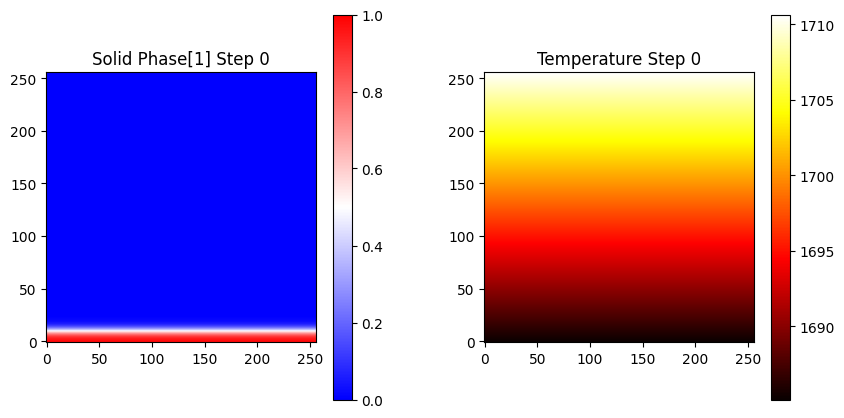

In [5]:
# --- 初期化 ---
phi_cpu = np.zeros((number_of_grain, nx, ny), dtype=np.float32)
# (初期配置のロジックは質問のものをそのまま使用)
seed_height = 10
factor = 2 / delta
for m in range(ny):
    y = m * dy
    dist = y - (seed_height * dy)
    phi_solid = 0.5 * (1.0 - np.tanh(factor * dist))
    phi_cpu[1, :, m] = phi_solid
    phi_cpu[0, :, m] = 1.0 - phi_solid

temp_cpu = np.zeros((nx, ny), dtype=np.float32)
for m in range(ny):
    temp_cpu[:, m] = T_melt - 1 + G * (m - seed_height) * dy

fig = plt.figure(figsize=(10,5))
plt.subplots_adjust(wspace=0.3) 
plt.subplot(1,2,1)
plt.imshow(phi_cpu[1].T, cmap='bwr', origin='lower',vmax=1.0,vmin=0.0)
plt.colorbar()
plt.title(f"Solid Phase[1] Step 0")

plt.subplot(1,2,2)
plt.imshow(temp_cpu.T, cmap='hot', origin='lower')
plt.title(f"Temperature Step 0")
plt.colorbar()
plt.savefig(f"{out_dir}/step_0.png", dpi=300)
plt.show()

In [6]:
# GPUメモリへ転送
d_phi = cuda.to_device(phi_cpu)
d_phi_new = cuda.to_device(phi_cpu)
d_temp = cuda.to_device(temp_cpu)
d_wij = cuda.to_device(wij)
d_aij = cuda.to_device(aij)
d_mij = cuda.to_device(mij)

In [7]:
# CUDA実行構成
threadsperblock = (16, 16)
blockspergrid_x = math.ceil(nx / threadsperblock[0])
blockspergrid_y = math.ceil(ny / threadsperblock[1])
blockspergrid = (blockspergrid_x, blockspergrid_y)

Step 50000 done.


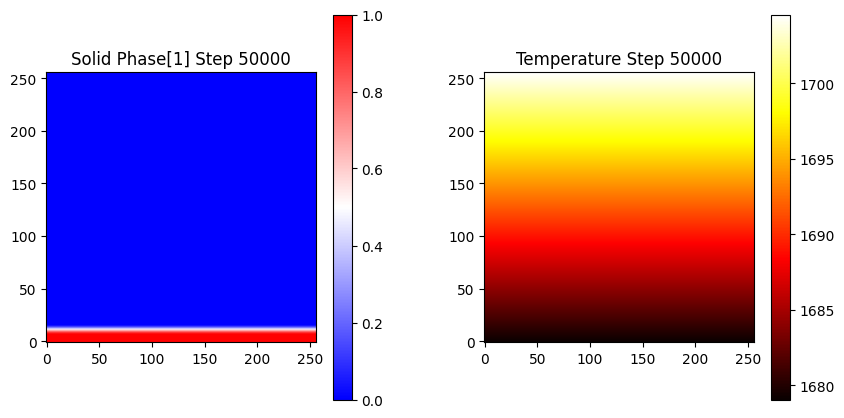

Step 100000 done.


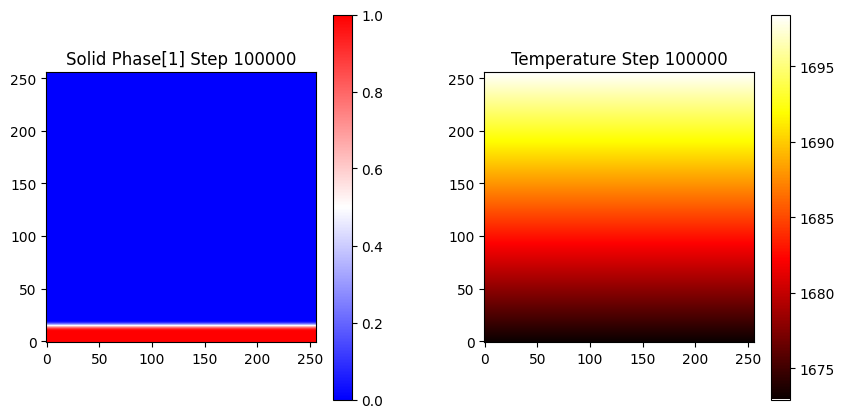

Step 150000 done.


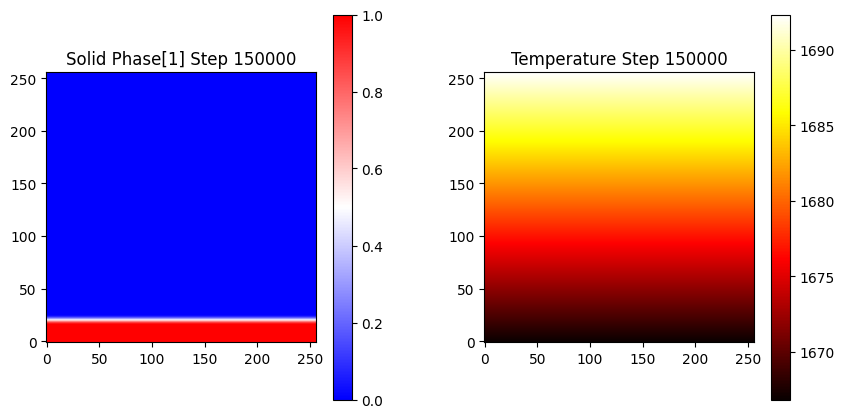

Step 200000 done.


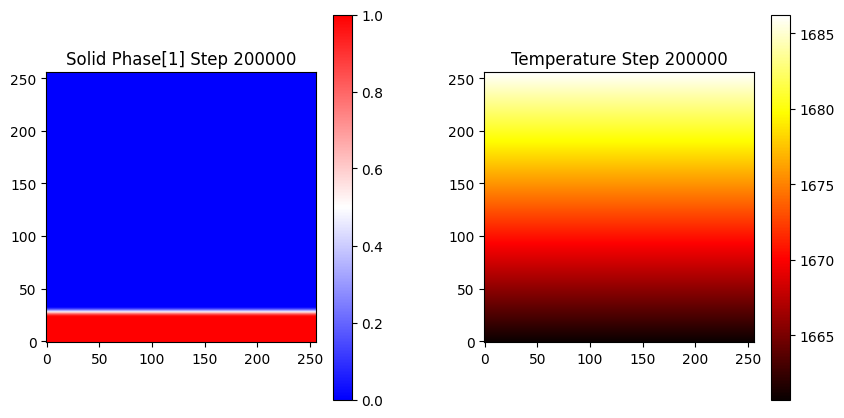

Step 250000 done.


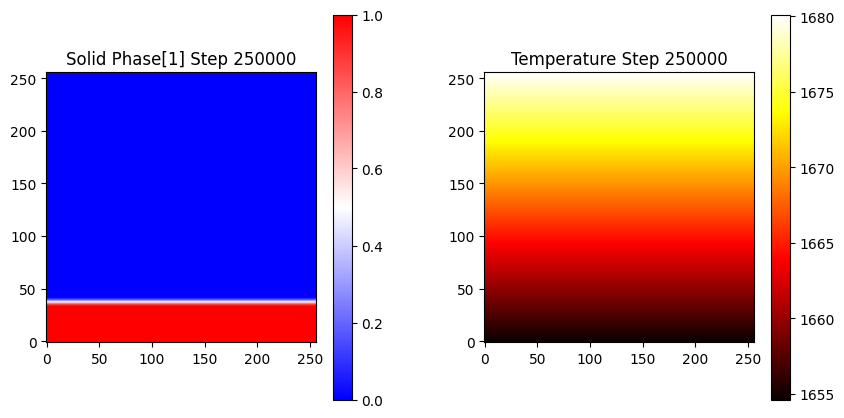

Step 300000 done.


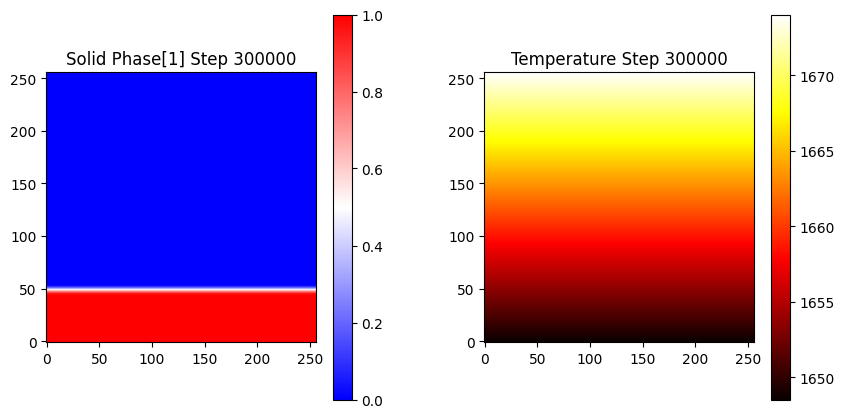

Step 350000 done.


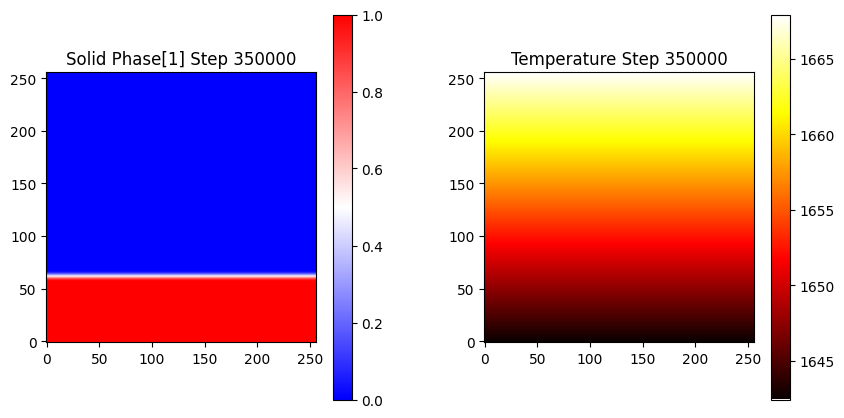

Step 400000 done.


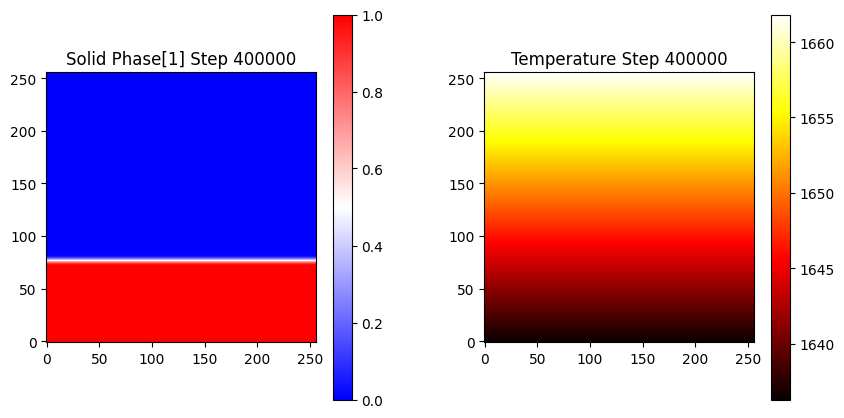

Step 450000 done.


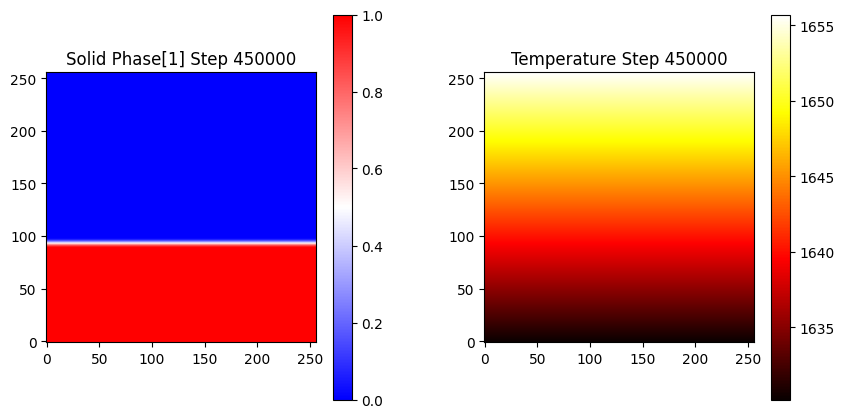

Step 500000 done.


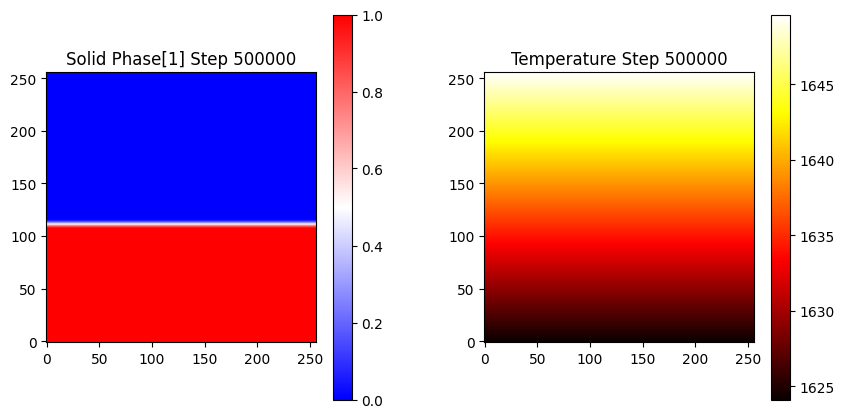

Step 550000 done.


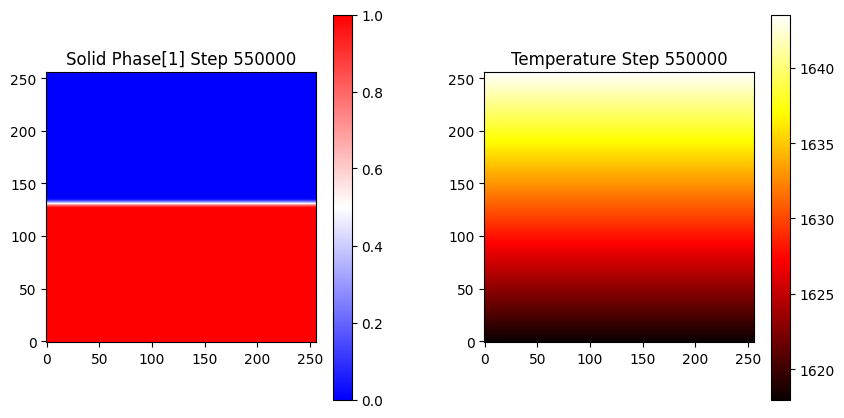

Step 600000 done.


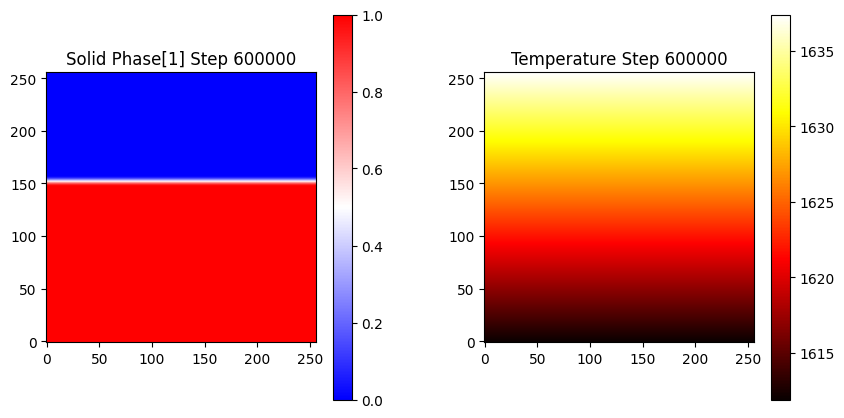

Step 650000 done.


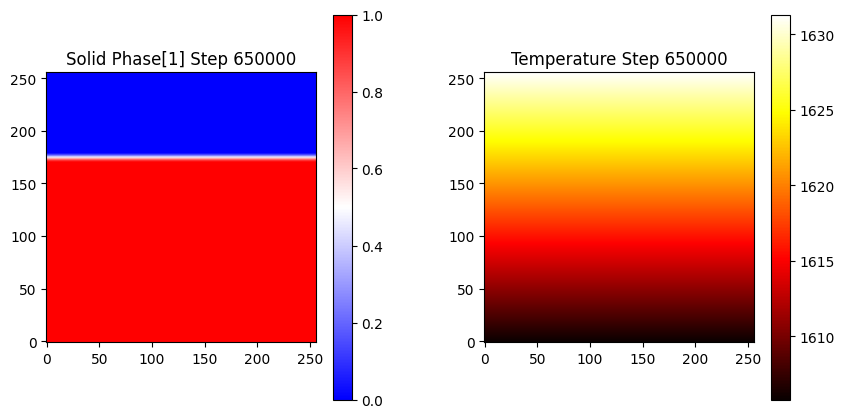

Step 700000 done.


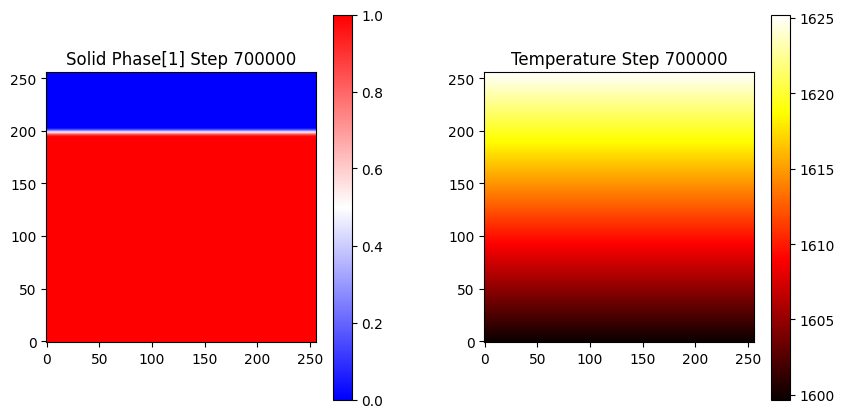

Step 750000 done.


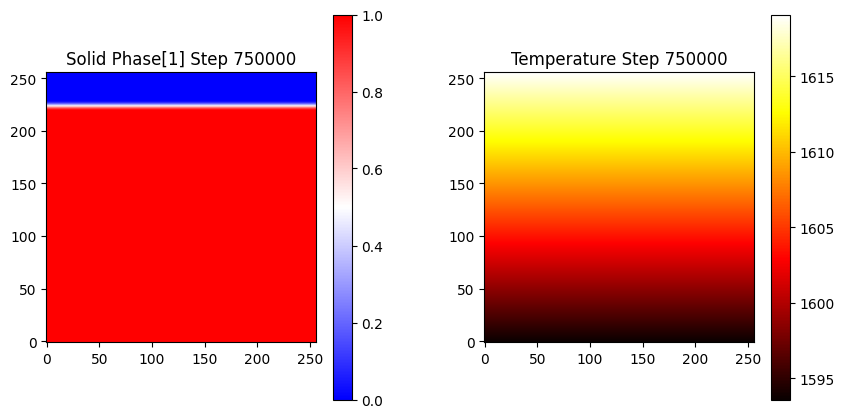

Step 800000 done.


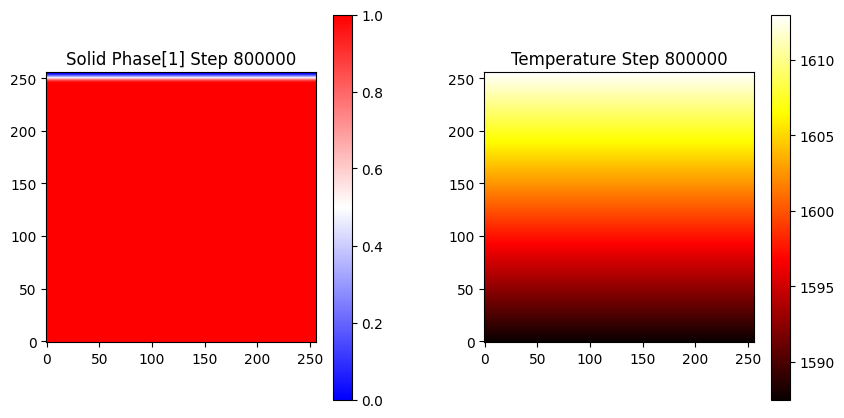

Step 850000 done.


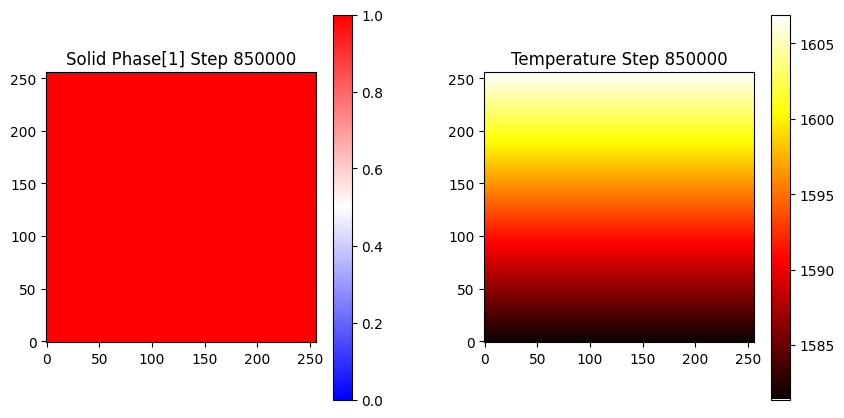

Step 900000 done.


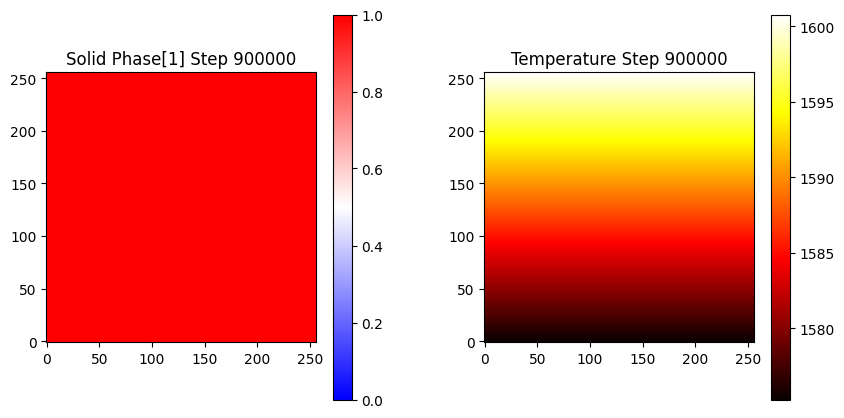

Step 950000 done.


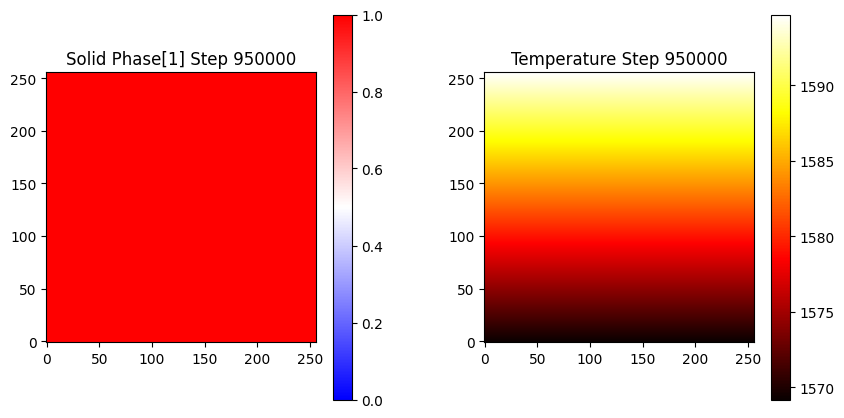

Step 1000000 done.


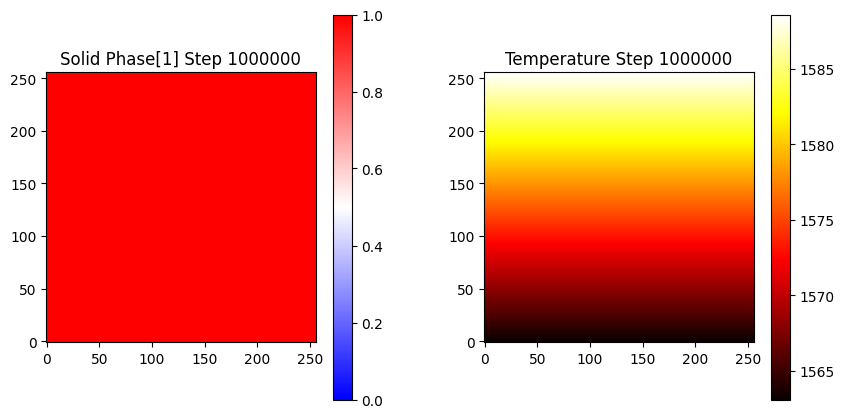

In [8]:
# --- メインループ ---
cooling_rate = G * V_pulling * dt

for nstep in range(1, nsteps + 1):
    # 温度更新
    kernel_update_temp[blockspergrid, threadsperblock](d_temp, cooling_rate, nx, ny)
    
    # フェーズフィールド更新
    kernel_update_phasefield[blockspergrid, threadsperblock](
        d_phi, d_phi_new, d_temp, d_wij, d_aij, d_mij, nx, ny, number_of_grain, dx, dt, T_melt, latent
    )
    
    # ポインタの入れ替え（d_phiに最新結果を入れる）
    d_phi, d_phi_new = d_phi_new, d_phi

    if nstep % 50000 == 0:
        current_phi = d_phi.copy_to_host()
        current_temp = d_temp.copy_to_host()
        print(f"Step {nstep} done.")
        
        fig = plt.figure(figsize=(10,5))
        plt.subplots_adjust(wspace=0.3) 
        plt.subplot(1,2,1)
        plt.imshow(current_phi[1].T, cmap='bwr', origin='lower',vmax=1.0,vmin=0.0)
        plt.colorbar()
        plt.title(f"Solid Phase[1] Step {nstep}")

        plt.subplot(1,2,2)
        plt.imshow(current_temp.T, cmap='hot', origin='lower')
        plt.title(f"Temperature Step {nstep}")
        plt.colorbar()
        plt.savefig(f"{out_dir}/step_{nstep:06d}.png", dpi=300)
        plt.show()
